# pLLPS Scores Analysis by Function
Analysis of pLLPS (Phase-separating tendency) scores across different functional protein categories.

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

## Load pLLPS Scores Data

In [2]:
# Define the path to pLLPS scores by function
pllps_dir = Path('/workspaces/mem_prot_llps/results/functional_group_networks/pllps_by_function')

# Load all pLLPS CSVs and combine them with function category
dfs = []
for csv_file in sorted(pllps_dir.glob('*_pllps.csv')):
    function_name = csv_file.stem.replace('_pllps', '')
    df = pd.read_csv(csv_file)
    df['function'] = function_name
    dfs.append(df)

# Combine all dataframes
combined_df = pd.concat(dfs, ignore_index=True)

print(f"Total records loaded: {len(combined_df)}")
print(f"\nDataFrame shape: {combined_df.shape}")
print(f"\nColumns: {combined_df.columns.tolist()}")
print(f"\nFirst few rows:")
print(combined_df.head(10))

Total records loaded: 15373

DataFrame shape: (15373, 6)

Columns: ['Rank', 'UniProt_ID', 'STRING_ID', 'Protein_Names', 'pLLPS_Score', 'function']

First few rows:
   Rank UniProt_ID    STRING_ID  \
0     1     Q9UKN1  MUC12_HUMAN   
1     2     Q68DE3   USF3_HUMAN   
2     3     Q2KJY2  KI26B_HUMAN   
3     4     Q12816   TROP_HUMAN   
4     5     Q12955   ANK3_HUMAN   
5     6     P22105   TENX_HUMAN   
6     7     Q9HBL0  TENS1_HUMAN   
7     8     P39060  COIA1_HUMAN   
8     9     Q5D862  FILA2_HUMAN   
9    10     Q07092  COGA1_HUMAN   

                                       Protein_Names  pLLPS_Score  function  
0              Mucin-12 (MUC-12) (Mucin-11) (MUC-11)          1.0  adhesion  
1  Basic helix-loop-helix domain-containing prote...          1.0  adhesion  
2                        Kinesin-like protein KIF26B          1.0  adhesion  
3                        Trophinin (MAGE-D3 antigen)          1.0  adhesion  
4                      Ankyrin-3 (ANK-3) (Ankyrin-G)        

## Count Scores Above Threshold (0.75)

In [3]:
# Find the pLLPS score column (likely 'pLLPS' or similar)
pllps_col = [col for col in combined_df.columns if 'pllps' in col.lower() or 'score' in col.lower()][0]
print(f"Using column: {pllps_col}")

# Calculate counts above 0.75 for each function
threshold = 0.75
high_scores_by_function = combined_df.groupby('function').apply(
    lambda x: (x[pllps_col] > threshold).sum()
).sort_values(ascending=False)

# Calculate total counts and percentages
total_by_function = combined_df.groupby('function').size()
high_scores_pct = (high_scores_by_function / total_by_function * 100).round(2)

# Create summary dataframe
summary_df = pd.DataFrame({
    'Function': high_scores_by_function.index,
    'Count > 0.75': high_scores_by_function.values,
    'Total': total_by_function[high_scores_by_function.index].values,
    'Percentage': high_scores_pct.values
}).reset_index(drop=True).sort_values('Count > 0.75', ascending=False)

print(f"\n{'='*70}")
print(f"pLLPS Scores Above 0.75 by Function")
print(f"{'='*70}")
print(summary_df.to_string(index=False))
print(f"\nTotal proteins with pLLPS > 0.75: {summary_df['Count > 0.75'].sum()}")
print(f"Total proteins analyzed: {summary_df['Total'].sum()}")

Using column: pLLPS_Score

pLLPS Scores Above 0.75 by Function
                          Function  Count > 0.75  Total  Percentage
              transcription_factor           752   1109       28.30
                        structural           658   1770       20.96
                          receptor           648   3218       13.17
                            kinase           454   1500       27.40
                            ligase           240    872       40.43
                         hydrolase           238    986       24.14
                          adhesion           238    841       20.00
                            gtpase           157    573       30.27
                       phosphatase           140    427       27.52
                       transferase           115    528       48.21
                       ion_channel            95    475        5.94
                  nuclear_receptor            94    195       32.79
                          protease            82    5

/tmp/ipykernel_30885/2040650719.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  high_scores_by_function = combined_df.groupby('function').apply(


## Statistics by Function

In [4]:
# Calculate detailed statistics for each function
stats_by_function = combined_df.groupby('function')[pllps_col].agg([
    'count',
    'mean',
    'median',
    'std',
    'min',
    'max'
]).round(4).sort_values('mean', ascending=False)

stats_by_function.columns = ['Count', 'Mean', 'Median', 'Std Dev', 'Min', 'Max']
print(f"\n{'='*90}")
print(f"Detailed pLLPS Statistics by Function")
print(f"{'='*90}")
print(stats_by_function.to_string())


Detailed pLLPS Statistics by Function
                                    Count    Mean  Median  Std Dev   Min  Max
function                                                                     
transcription_factor                 1109  0.7771    0.95   0.2911  0.10  1.0
nuclear_receptor                      195  0.6279    0.72   0.3444  0.10  1.0
guanine_nucleotide_exchange_factor    188  0.6043    0.62   0.3276  0.11  1.0
structural                           1770  0.5482    0.49   0.3460  0.06  1.0
receptor_tyrosine_kinase              111  0.5174    0.39   0.3228  0.11  1.0
phosphatase                           427  0.5107    0.40   0.3363  0.10  1.0
adhesion                              841  0.5034    0.40   0.3153  0.06  1.0
kinase                               1500  0.5004    0.39   0.3279  0.06  1.0
gtpase                                573  0.4899    0.37   0.3250  0.10  1.0
ligase                                872  0.4813    0.36   0.3210  0.06  1.0
hydrolase                

## Box Plot: pLLPS Score Distribution by Function

/tmp/ipykernel_30885/3712476522.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


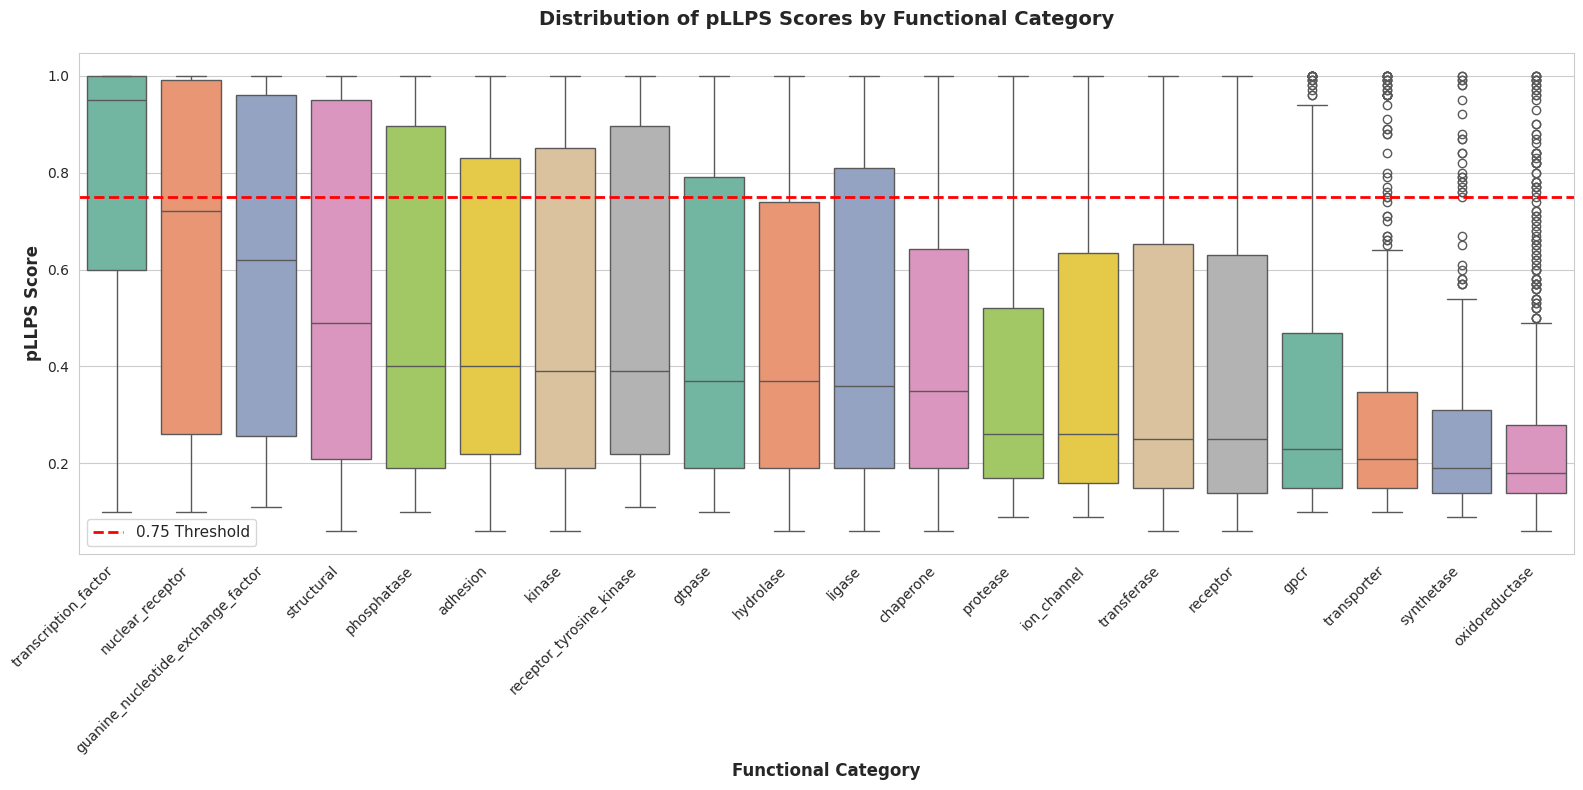

Box plot created showing pLLPS score distributions.


In [5]:
# Create a box plot sorted by median pLLPS score
fig, ax = plt.subplots(figsize=(16, 8))

# Sort functions by median for better visualization
function_order = combined_df.groupby('function')[pllps_col].median().sort_values(ascending=False).index

sns.boxplot(
    data=combined_df,
    x='function',
    y=pllps_col,
    order=function_order,
    palette='Set2',
    ax=ax
)

# Add horizontal line for threshold
ax.axhline(y=0.75, color='red', linestyle='--', linewidth=2, label='0.75 Threshold')

ax.set_xlabel('Functional Category', fontsize=12, fontweight='bold')
ax.set_ylabel('pLLPS Score', fontsize=12, fontweight='bold')
ax.set_title('Distribution of pLLPS Scores by Functional Category', fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11)
ax.tick_params(axis='x', rotation=45)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Box plot created showing pLLPS score distributions.")

## Violin Plot: Alternative Visualization

/tmp/ipykernel_30885/444324129.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


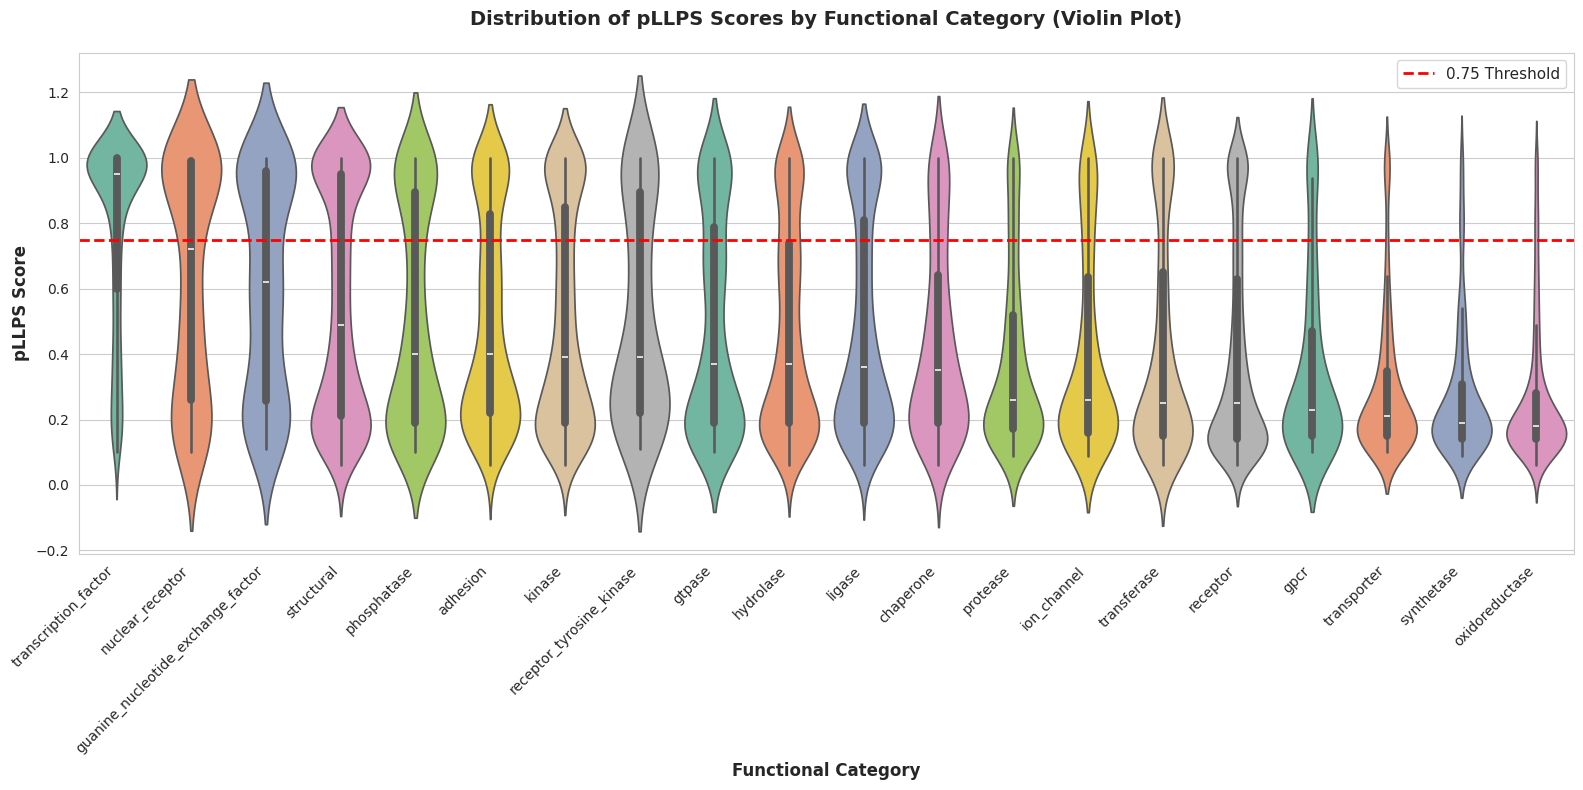

Violin plot created showing pLLPS score distributions.


In [6]:
fig, ax = plt.subplots(figsize=(16, 8))

sns.violinplot(
    data=combined_df,
    x='function',
    y=pllps_col,
    order=function_order,
    palette='Set2',
    ax=ax
)

# Add horizontal line for threshold
ax.axhline(y=0.75, color='red', linestyle='--', linewidth=2, label='0.75 Threshold')

ax.set_xlabel('Functional Category', fontsize=12, fontweight='bold')
ax.set_ylabel('pLLPS Score', fontsize=12, fontweight='bold')
ax.set_title('Distribution of pLLPS Scores by Functional Category (Violin Plot)', fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Violin plot created showing pLLPS score distributions.")

## Functional Categories with Highest pLLPS Scores

In [7]:
# Top 5 functions with highest mean pLLPS scores
top_5_mean = stats_by_function.nlargest(5, 'Mean')
print("\n" + "="*70)
print("Top 5 Functions by Mean pLLPS Score")
print("="*70)
print(top_5_mean.to_string())

# Top 5 functions with most high scores (>0.75)
top_5_count = summary_df.nlargest(5, 'Count > 0.75')
print("\n" + "="*70)
print("Top 5 Functions by Count of pLLPS > 0.75")
print("="*70)
print(top_5_count.to_string(index=False))


Top 5 Functions by Mean pLLPS Score
                                    Count    Mean  Median  Std Dev   Min  Max
function                                                                     
transcription_factor                 1109  0.7771    0.95   0.2911  0.10  1.0
nuclear_receptor                      195  0.6279    0.72   0.3444  0.10  1.0
guanine_nucleotide_exchange_factor    188  0.6043    0.62   0.3276  0.11  1.0
structural                           1770  0.5482    0.49   0.3460  0.06  1.0
receptor_tyrosine_kinase              111  0.5174    0.39   0.3228  0.11  1.0

Top 5 Functions by Count of pLLPS > 0.75
            Function  Count > 0.75  Total  Percentage
transcription_factor           752   1109       28.30
          structural           658   1770       20.96
            receptor           648   3218       13.17
              kinase           454   1500       27.40
              ligase           240    872       40.43
